In [1]:
import pandas as pd
import ast
import json
import torch
from torch.utils.data import DataLoader, Subset
from torch.utils.data import Dataset
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import colorsys

In [9]:
#### Utility functions for the dataset ####
def find_key_instances_in_order(dict1, dict2, target_key):
    results = []

    def search(d1, d2):
        # Handle entries from d1
        for key, value in d1.items():
            if key == target_key:
                results.append(value)
            if isinstance(value, dict):
                search(value, d2.get(key, {}))
            elif isinstance(value, list):
                for item in value:
                    if isinstance(item, dict):
                        search(item, {})

        # Handle entries from d2 that were not already handled in d1
        for key, value in d2.items():
            if key == target_key:
                results.append(value)
            if isinstance(value, dict) and key not in d1:
                search({}, value)
            elif isinstance(value, list) and key not in d1:
                for item in value:
                    if isinstance(item, dict):
                        search({}, item)

    search(dict1, dict2)
    return results


def get_player_names(data):
    names = []
    for i in range(len(data)):
        match_name = (data['home'][i]['roster']|data['away'][i]['roster']).keys()
        names += list(match_name)
    unique_names = list(set(names))
    
    return unique_names

def get_player_stats(data):
    player_names = get_player_names(data)
    stats={}
    for name in player_names:
        stats[name]=find_key_instances_in_order(data['home'], data['away'], name)
    
    return stats

def get_unique_stats(data):
    
    unique_stats = []
    for player in data.keys():
        player_stat_names = {}
        for item in data[player]:
            player_stat_names=player_stat_names|item['statistics']
        player_stat_names=list(player_stat_names.keys())
        unique_stats += player_stat_names
    unique_stats=list(set(unique_stats))
    
    return unique_stats

def get_unique_team_stats(data):
    stat_headers = data.columns[17:]
    stat_headers=[header.replace('away_','').replace('home_','') for header in stat_headers]
    stat_headers =list(set(stat_headers))
    
    return stat_headers
    
def build_char_vocab(player_names):
    all_names = [name.lower() for name in player_names]
    all_chars = ''.join(all_names)
    unique_chars = set(all_chars)

    char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(unique_chars))}  # Reserve 0 for <PAD>
    char_to_idx['<PAD>'] = 0
    char_to_idx['<UNK>'] = len(char_to_idx) + 1
    return char_to_idx

def divide_stats(stat_type = None):
        #Define the division of stats
        if stat_type is None:
            periods = ['total','45_min','90_min']
            attack = ['accuratecross_all','accuratecross_value','accuratelongballs_all','accuratelongballs_value',
            'accuratepasses','accuratethroughball','bigchancecreated','bigchancescored','cornerkicks',
            'dribblespercentage_all','dribblespercentage_value','finalthirdentries', #deleted duelwonpercent
            'fouledfinalthird','freekicks','passes','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox']
            defense = ['aerialduelspercentage_all','aerialduelspercentage_value','ballpossession','ballrecovery',
            'goalkeepersaves','groundduelspercentage_all','groundduelspercentage_value','interceptionwon',
            'throwins','totalclearance','wontacklepercent_all','wontacklepercent_value']
            mistakes = ['bigchancemissed','blockedscoringattempt','dispossessed','hitwoodwork','offsides',
            'redcards','shotsoffgoal','yellowcards']
            #extra=['total_goalsprevented']
        
        if stat_type == 'corners':
            periods = ['total','45_min','90_min']
            #periods = ['total']
            attack = ['accuratecross_all','accuratecross_value','cornerkicks',
            'fouledfinalthird','freekicks','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox','blockedscoringattempt']
            defense = ['goalkeepersaves']
            mistakes = []
            #extra=['total_goalsprevented']

        if stat_type == 'older_stats':
            periods = ['total','45_min','90_min']
            attack = ['accuratepasses','accuratethroughball','bigchancecreated','bigchancescored','cornerkicks',
            'finalthirdentries', #deleted duelwonpercent
            'fouledfinalthird','freekicks','passes','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox']
            defense = ['ballpossession',
            'goalkeepersaves','interceptionwon',
            'throwins','totalclearance','bigchancemissed','blockedscoringattempt','dispossessed','hitwoodwork','offsides']
            mistakes = []
            #extra=['total_goalsprevented']
        
        atk_headers = [f'{period}_{header}' for period in periods for header in attack]
        def_headers = [f'{period}_{header}' for period in periods for header in defense]
        mis_headers = [f'{period}_{header}' for period in periods for header in mistakes]
        
        def_headers = def_headers + mis_headers
        
        return atk_headers, def_headers

#### Utility functions for creating the data splits ####

def extract_league_name(league_str):
    """
    Extract the league name by removing the last two underscore-separated parts,
    which represent the season years (e.g., "2023_2024").
    """
    parts = league_str.split('_')
    if len(parts) > 2:
        return '_'.join(parts[:-2])
    return league_str

def split_and_merge_leagues(leagues, train_p, val_p, test_p):
    if not (train_p + val_p + test_p == 1.0):
        raise ValueError("Proportions train_p, val_p, and test_p must sum up to 1.0")

    train_df = pd.DataFrame()
    val_df = pd.DataFrame()
    test_df = pd.DataFrame()

    standard_columns = None  # To hold the standard column order

    # Dictionary to map league names to indices
    league_indices = {}

    for league in leagues:
        # Extract the base league name
        league_name = extract_league_name(league)
        # Assign a new index if we haven't seen this league before
        if league_name not in league_indices:
            league_indices[league_name] = len(league_indices)
        current_league_index = league_indices[league_name]
        
        # Read CSV files
        df = pd.read_csv(f'xDiyo_data_heatmaps/{league}.csv', 
                        converters={'home_shots': ast.literal_eval, 'away_shots': ast.literal_eval,
                                'home_heatmap': ast.literal_eval,'away_heatmap': ast.literal_eval})
        lp = pd.read_csv(f'xDiyo_data_heatmaps/{league}_lineups.csv', 
                        converters={'home': ast.literal_eval, 'away': ast.literal_eval})

        # Extract formations from lp and add them as columns in df
        df['home_formation'] = lp.apply(lambda row: row['home']['formation'], axis=1)
        df['away_formation'] = lp.apply(lambda row: row['away']['formation'], axis=1)

        # Normalize standings
        df['home_standing'] = df['home_standing'] / df['home_standing'].max()
        df['away_standing'] = df['away_standing'] / df['away_standing'].max()

        # Add league_index column to mark league membership
        df['league_index'] = current_league_index

        # Set the standard column order from the first file processed
        if standard_columns is None:
            standard_columns = df.columns.tolist()

        # Align current DataFrame's columns to the standard order
        df = df.reindex(columns=standard_columns)

        # Calculate split indices
        n_matches = len(df)
        train_end = int(train_p * n_matches)
        val_end = train_end + int(val_p * n_matches)

        # Split the data
        train_portion = df.iloc[:train_end]
        val_portion = df.iloc[train_end:val_end]
        test_portion = df.iloc[val_end:]

        # Merge portions into respective DataFrames
        train_df = pd.concat([train_df, train_portion], axis=0)
        val_df = pd.concat([val_df, val_portion], axis=0)
        test_df = pd.concat([test_df, test_portion], axis=0)

    # Drop the 'index' column if it exists
    for df in [train_df, val_df, test_df]:
        if 'index' in df.columns:
            df.drop('index', axis=1, inplace=True)

    # Fill missing values with 0 and reset indexes
    for df in [train_df, val_df, test_df]:
        df.fillna(0, inplace=True)
        df.reset_index(drop=True, inplace=True)

    # Return the splits along with the league mapping dictionary
    return train_df, val_df, test_df, league_indices


def calculate_mean_std(train_df, columns):
    """
    Calculates league-specific mean and standard deviation statistics.
    
    For each league (determined by 'league_index' in train_df), this function:
    - Stacks the home and away columns (after renaming them to remove the prefixes).
    - Computes the mean and standard deviation for the stacked data.
    
    Returns:
        A dictionary where each key is a league index and the value is a DataFrame with 
        two rows ("mean" and "std") corresponding to the computed statistics.
    """
    # Define the home and away column names from the provided columns list
    home_columns = [f"home_{col}" for col in columns]
    away_columns = [f"away_{col}" for col in columns]

    # Verify that all expected columns exist in the DataFrame
    if not (set(home_columns).issubset(train_df.columns) and set(away_columns).issubset(train_df.columns)):
        raise ValueError("Home or away columns derived from the provided list are missing in the training DataFrame")

    league_stats = {}
    # Process each league (sorted by league_index for consistency)
    for league in sorted(train_df['league_index'].unique()):
        sub_df = train_df[train_df['league_index'] == league]
        # Stack the home and away columns after renaming to remove prefixes
        stacked_data = pd.concat([
            sub_df[home_columns].rename(columns=lambda x: x.replace("home_", "")),
            sub_df[away_columns].rename(columns=lambda x: x.replace("away_", ""))
        ], axis=0)
        # Calculate mean and standard deviation on the stacked data
        mean_values = stacked_data.mean()
        std_values = stacked_data.std()
        result_df = pd.DataFrame([mean_values, std_values], index=["mean", "std"])
        league_stats[league] = result_df.reset_index(drop=True)
    return league_stats

def extract_averages(league_avgs, headers):
    """
    Extracts and stacks league-specific mean and standard deviation statistics.
    
    Given a dictionary (league_avgs) where each key is a league index and each value is 
    a DataFrame with two rows ("mean" and "std"), this function extracts the statistics 
    corresponding to the provided headers for each league.
    
    It returns two tensors:
    - The first tensor stacks the mean vectors from all leagues.
    - The second tensor stacks the standard deviation vectors from all leagues.
    
    The first dimension of the output tensors corresponds to the league index.
    """
    # Ensure a consistent order of leagues
    league_indices = sorted(league_avgs.keys())
    mu_list = []
    sigma_list = []
    
    # Iterate over leagues in sorted order and extract the vectors
    for league in league_indices:
        avgs = league_avgs[league]
        mu_row = avgs.iloc[0]
        sigma_row = avgs.iloc[1]
        mu_vector = [mu_row.get(stat, 0) for stat in headers]
        sigma_vector = [sigma_row.get(stat, 0) for stat in headers]
        mu_list.append(mu_vector)
        sigma_list.append(sigma_vector)
    
    # Create and return torch tensors with league as the first dimension
    return torch.tensor(mu_list, dtype=torch.float), torch.tensor(sigma_list, dtype=torch.float)


def convert_team_names_to_ids(team_name, team2id):
    """
    Converts a team name into integer IDs using team2id.
    """
    return team2id[team_name] if team_name in team2id else team2id["<PAD>"]

import torch

def process_heatmap_data(heatmap_data, n_x, n_y, reverse_x=False, reverse_y=False, flatten=True, density=False):
    """
    Processes heatmap data and returns two torch tensors (either flattened or 2D) indicating either the count 
    or the density (normalized counts) of points in each cell of an n_x x n_y grid for the players and the goalkeeper.

    Parameters:
    heatmap_data (dict): Dictionary containing "playerPoints" and "goalkeeperPoints". Each is a list of dictionaries with "x" and "y" keys.
    n_x (int): Number of divisions (cells) along the x-axis.
    n_y (int): Number of divisions (cells) along the y-axis.
    reverse_x (bool): If True, the x coordinate is reflected (i.e., 100 - x) before processing.
    reverse_y (bool): If True, the y coordinate is reflected (i.e., 100 - y) before processing.
    flatten (bool): If True, returns a flattened 1D tensor for each; otherwise, returns a 2D tensor of shape (n_y, n_x).
    density (bool): If True, the counts in each cell are normalized by the total count to return a density value (each cell is a fraction between 0 and 1).
    Recommended to do reverse (x,y) = (False,True) for Home and (x,y) = (True,False) for Away
    Returns:
    tuple: (player_tensor, goalkeeper_tensor) where each is a torch tensor representing the count or density of points 
             falling in each cell. If flatten is True, the tensor is of shape (n_x * n_y,), otherwise (n_y, n_x).
    """
    # Court dimensions
    court_length = 1.5  # along x-axis
    court_width = 1.0   # along y-axis

    # Compute cell sizes in terms of the actual court dimensions.
    cell_width = court_length / n_x
    cell_height = court_width / n_y

    # Create zero-filled tensors for counts.
    player_counts = torch.zeros((n_y, n_x), dtype=torch.float32)
    goalkeeper_counts = torch.zeros((n_y, n_x), dtype=torch.float32)

    # Process the player points:
    for point in heatmap_data.get("playerPoints", []):
        # Get the percentage positions along x and y.
        x_perc = point.get("x", 0)
        y_perc = point.get("y", 0)
        if reverse_x:
            x_perc = 100 - x_perc  # Reflect the x-coordinate if needed
        if reverse_y:
            y_perc = 100 - y_perc  # Reflect the y-coordinate if needed
        
        # Convert percentage to actual court coordinates.
        x_coord = (x_perc / 100.0) * court_length
        y_coord = (y_perc / 100.0) * court_width

        # Determine grid cell indices (using int() for floor division).
        col = int(x_coord / cell_width)
        row = int(y_coord / cell_height)

        # Ensure indices remain within bounds.
        if col >= n_x:
            col = n_x - 1
        if row >= n_y:
            row = n_y - 1

        player_counts[row, col] += 1

    # Process the goalkeeper points:
    for point in heatmap_data.get("goalkeeperPoints", []):
        x_perc = point.get("x", 0)
        y_perc = point.get("y", 0)
        if reverse_x:
            x_perc = 100 - x_perc
        if reverse_y:
            y_perc = 100 - y_perc
        
        x_coord = (x_perc / 100.0) * court_length
        y_coord = (y_perc / 100.0) * court_width

        col = int(x_coord / cell_width)
        row = int(y_coord / cell_height)
        if col >= n_x:
            col = n_x - 1
        if row >= n_y:
            row = n_y - 1

        goalkeeper_counts[row, col] += 1

    # If density flag is true, normalize counts to get a density.
    if density:
        total_player_points = player_counts.sum()
        total_goalkeeper_points = goalkeeper_counts.sum()
        if total_player_points > 0:
            player_counts = player_counts / total_player_points
        if total_goalkeeper_points > 0:
            goalkeeper_counts = goalkeeper_counts / total_goalkeeper_points

    # Return flattened or 2D tensors based on the flatten flag.
    if flatten:
        player_tensor = player_counts.flatten()
        goalkeeper_tensor = goalkeeper_counts.flatten()
    else:
        player_tensor = player_counts
        goalkeeper_tensor = goalkeeper_counts

    return player_tensor, goalkeeper_tensor

def create_single_color_colormap(color='red', lightness_increase=0.1, lightness_decrease=0.05):
    """
    Creates a custom colormap that transitions from a light version of the given color
    to a dark version.

    Parameters:
    color (str): The base color (e.g., 'red', 'blue').
    lightness_increase (float): Amount to increase lightness to get the low-density color.
    lightness_decrease (float): Amount to decrease lightness to get the high-density color.

    Returns:
    LinearSegmentedColormap: A matplotlib colormap object.
    """
    # Convert the base color to RGB and then to HLS.
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    
    # Compute a light variant by increasing the lightness (capped at 1.0)
    light_L = min(1.0, l + lightness_increase)
    # Compute a dark variant by decreasing the lightness (down to a minimum of 0.0)
    dark_L = max(0.0, l - lightness_decrease)
    
    light_variant = colorsys.hls_to_rgb(h, light_L, s)
    dark_variant = colorsys.hls_to_rgb(h, dark_L, s)
    
    return LinearSegmentedColormap.from_list('custom_single_color', [light_variant, dark_variant])

def plot_heatmap(heatmap_tensor, n_x, n_y, title="Heatmap", cmap=None):
    """
    Plots a single heatmap given as a flattened torch tensor, using a custom colormap.
    
    Parameters:
      heatmap_tensor (torch.Tensor or list): Flattened tensor (n_x * n_y) of heatmap density.
    n_x (int): Number of divisions along the x-axis.
    n_y (int): Number of divisions along the y-axis.
    title (str): Title for the plot.
    cmap: Colormap for the plot. If None, a custom single-color colormap (from white to red) will be used.
    """
    if cmap is None:
        cmap = create_single_color_colormap('red')
    
    # Ensure tensor and reshape
    if not isinstance(heatmap_tensor, torch.Tensor):
        heatmap_tensor = torch.tensor(heatmap_tensor, dtype=torch.float32)
    grid = heatmap_tensor.reshape(n_y, n_x)
    
    plt.figure(figsize=(6, 5))
    im = plt.imshow(grid, origin="upper", interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.xlabel("X Grid")
    plt.ylabel("Y Grid")
    plt.colorbar(im, label="Density")
    plt.tight_layout()
    plt.show()

def plot_team_heatmaps(player_tensor, goalkeeper_tensor, n_x, n_y,
                    player_title="Player Heatmap", goalkeeper_title="Goalkeeper Heatmap", cmap=None):
    """
    Plots two heatmaps side-by-side (one for player points and one for goalkeeper points)
    using a custom colormap that ranges from white (low density) to a saturated color.
    
    Parameters:
    player_tensor (torch.Tensor or list): Flattened tensor for the player heatmap.
    goalkeeper_tensor (torch.Tensor or list): Flattened tensor for the goalkeeper heatmap.
    n_x (int): Number of grid divisions along the x-axis.
    n_y (int): Number of grid divisions along the y-axis.
    player_title (str): Title for the player heatmap.
    goalkeeper_title (str): Title for the goalkeeper heatmap.
    cmap: Colormap for the plots. If None, a custom single-color colormap (from white to red) will be used.
    """
    if cmap is None:
        cmap = create_single_color_colormap('red')
    
    # Prepare player tensor
    if not isinstance(player_tensor, torch.Tensor):
        player_tensor = torch.tensor(player_tensor, dtype=torch.float32)
    player_grid = player_tensor.reshape(n_y, n_x)
    
    # Prepare goalkeeper tensor
    if not isinstance(goalkeeper_tensor, torch.Tensor):
        goalkeeper_tensor = torch.tensor(goalkeeper_tensor, dtype=torch.float32)
    goalkeeper_grid = goalkeeper_tensor.reshape(n_y, n_x)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    im1 = axes[0].imshow(player_grid, origin="upper", interpolation="nearest", cmap=cmap)
    axes[0].set_title(player_title)
    axes[0].set_xlabel("X Grid")
    axes[0].set_ylabel("Y Grid")
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
    
    im2 = axes[1].imshow(goalkeeper_grid, origin="upper", interpolation="nearest", cmap=cmap)
    axes[1].set_title(goalkeeper_title)
    axes[1].set_xlabel("X Grid")
    axes[1].set_ylabel("Y Grid")
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
    
    plt.tight_layout()
    plt.show()

def plot_heatmap_marginals(heatmap, title_prefix=""):
    """
    Plots the marginal distributions along the X and Y axes for a given 2D heatmap tensor.
    
    Parameters:
        heatmap (torch.Tensor or list): A 2D tensor (n_y x n_x) or list of lists
        title_prefix (str): Optional prefix for plot titles
    """
    if isinstance(heatmap, list):
        heatmap = torch.tensor(heatmap, dtype=torch.float32)
    
    x_marginal = heatmap.sum(dim=0)  # Summing over rows gives X-axis marginal
    y_marginal = heatmap.sum(dim=1)  # Summing over columns gives Y-axis marginal

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].bar(range(len(x_marginal)), x_marginal.numpy())
    axs[0].set_title(f"{title_prefix} Marginal along X-axis")
    axs[0].set_xlabel("X bins")
    axs[0].set_ylabel("Density")

    axs[1].bar(range(len(y_marginal)), y_marginal.numpy())
    axs[1].set_title(f"{title_prefix} Marginal along Y-axis")
    axs[1].set_xlabel("Y bins")
    axs[1].set_ylabel("Density")

    plt.tight_layout()
    plt.show()



Player Heatmap Tensor (flattened):
tensor([[0.0044, 0.0103, 0.0059, 0.0177, 0.0177, 0.0207, 0.0118, 0.0074, 0.0044,
         0.0000, 0.0059, 0.0089],
        [0.0103, 0.0103, 0.0118, 0.0074, 0.0074, 0.0222, 0.0118, 0.0074, 0.0074,
         0.0103, 0.0030, 0.0000],
        [0.0030, 0.0118, 0.0177, 0.0133, 0.0133, 0.0207, 0.0207, 0.0177, 0.0059,
         0.0059, 0.0059, 0.0074],
        [0.0030, 0.0148, 0.0089, 0.0103, 0.0177, 0.0133, 0.0207, 0.0118, 0.0074,
         0.0074, 0.0030, 0.0103],
        [0.0118, 0.0177, 0.0059, 0.0133, 0.0103, 0.0074, 0.0103, 0.0118, 0.0103,
         0.0089, 0.0059, 0.0044],
        [0.0000, 0.0103, 0.0089, 0.0103, 0.0118, 0.0103, 0.0251, 0.0133, 0.0162,
         0.0074, 0.0089, 0.0044],
        [0.0044, 0.0015, 0.0148, 0.0074, 0.0148, 0.0266, 0.0222, 0.0118, 0.0192,
         0.0044, 0.0044, 0.0000],
        [0.0030, 0.0000, 0.0103, 0.0177, 0.0133, 0.0177, 0.0148, 0.0310, 0.0059,
         0.0030, 0.0059, 0.0044]])

Goalkeeper Heatmap Tensor (flattened):
tens

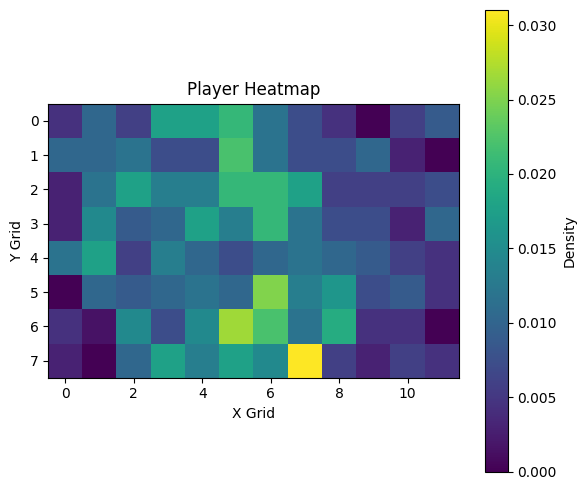

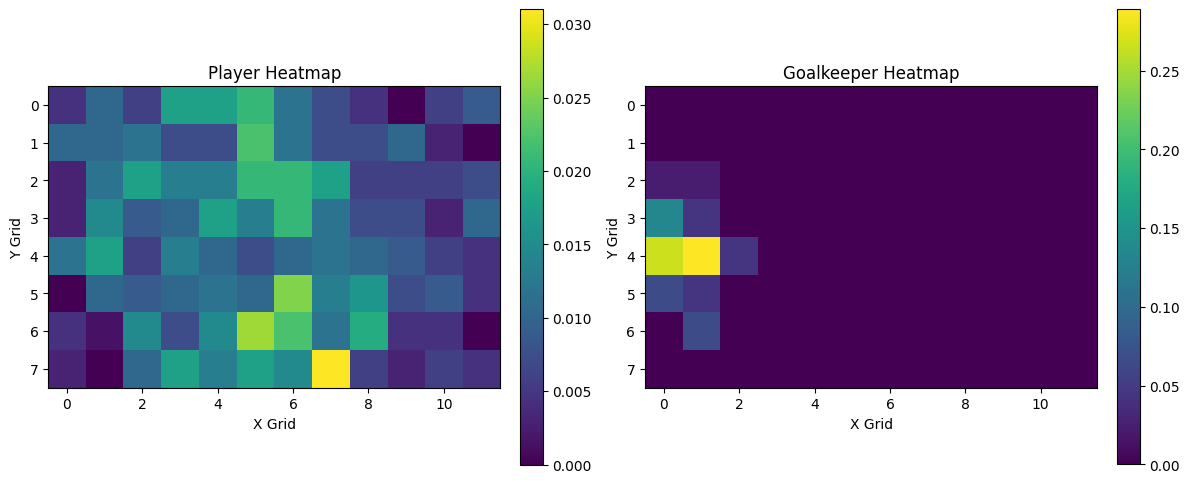

In [61]:
# Process the example heatmap into a 10x8 grid (for instance) with x-axis reversal turned off.
player_tensor, goalkeeper_tensor = process_heatmap_data(example_heatmap, n_x=12, n_y=8, reverse_x=False, reverse_y=True, flatten = False, density= True)

print("Player Heatmap Tensor (flattened):")
print(player_tensor)

print("\nGoalkeeper Heatmap Tensor (flattened):")
print(goalkeeper_tensor)
my_map = create_single_color_colormap('blue', lightness_increase=0.1, lightness_decrease=0.2)
# Plot a single heatmap (e.g., for players)
plot_heatmap(player_tensor, n_x=12, n_y=8, title="Player Heatmap", cmap='viridis')

# Plot both heatmaps side-by-side
plot_team_heatmaps(player_tensor, goalkeeper_tensor, n_x=12, n_y=8,
                    player_title="Player Heatmap", goalkeeper_title="Goalkeeper Heatmap", cmap='viridis')

In [3]:
class FootballDataset(Dataset):
    def __init__(self, league_df, max_seq_length, team2id, n_x, n_y, flatten_h=False, reverse_h=False, stat_type=None):
        self.league_df = league_df
        self.team2id = team2id
        self.flatten_h = flatten_h
        self.reverse_h = reverse_h
        self.stat_type = stat_type
        self.match_ids = league_df.index.tolist()  # match indices
        self.max_seq_length = max_seq_length + 1     # max number of matches per team sequence
        # New parameters for the heatmap grid dimensions
        self.n_x = n_x  # number of grid divisions along the x-axis
        self.n_y = n_y  # number of grid divisions along the y-axis

        self.atk_headers,self.def_headers,self.mis_headers = self.divide_stats()
        self.num_teams = len(league_df['home_team'].unique())
        self.team_history = self.build_team_history()
        self.atk_len, self.def_len = len(self.atk_headers), len(self.def_headers)+len(self.mis_headers)  # adjust if including mis_headers

    def __len__(self):
        return len(self.match_ids)

    def __getitem__(self, idx):
        match_id = self.match_ids[idx]
        league_row = self.league_df.loc[idx]
        
        # Determine match outcome: draw=0, home win=1, away win=-1
        home_score = league_row['home_score']
        away_score = league_row['away_score']
        if home_score == away_score:
            outcome = 0
        elif home_score > away_score:
            outcome = 1
        else:
            outcome = -1

        # Process team data
        home_team_id = league_row['home_id']
        away_team_id = league_row['away_id']
        home_data = self.process_team(team_id=home_team_id, current_match_id=match_id)
        away_data = self.process_team(team_id=away_team_id, current_match_id=match_id)

        sample = {
            'home_data': home_data,
            'away_data': away_data,
            'outcome': torch.tensor(outcome, dtype=torch.long),
            'league_index': torch.tensor(league_row['league_index'], dtype=torch.long),
        }
        return sample

    def process_team(self, team_id, current_match_id):
        # Retrieve historical team data for this team, before the current match.
        historical_team_data = self.get_historical_team_data(team_id, current_match_id)
        seq_length = min(len(historical_team_data), self.max_seq_length)
        
        # Prepare various sequences (standings, formations, scores, etc.).
        standings_sequence         = [match['standings'] for match in historical_team_data]
        enemy_standings_sequence   = [match['enemy_standings'] for match in historical_team_data]
        formations_sequence        = [match['formation'] for match in historical_team_data]
        enemy_formations_sequence  = [match['enemy_formation'] for match in historical_team_data]
        team_scores_sequence       = [[match['total_score'], match['score_45_min'], match['score_90_min']] for match in historical_team_data]
        enemy_scores_sequence      = [[match['enemy_total_score'], match['enemy_45_min'], match['enemy_90_min']] for match in historical_team_data]
        is_home_sequence           = [match['is_home'] for match in historical_team_data]
        enemy_is_home_sequence     = [match['enemy_is_home'] for match in historical_team_data]
        team_name_sequence         = [match['team_name'] for match in historical_team_data]
        team_index_sequence        = [match['team_index'] for match in historical_team_data]
        enemy_name_sequence        = [match['enemy_name'] for match in historical_team_data]
        enemy_index_sequence       = [match['enemy_index'] for match in historical_team_data]
        team_atk_sequence          = [match['team_atk'] for match in historical_team_data]
        team_def_sequence          = [match['team_def'] for match in historical_team_data]
        enemy_atk_sequence         = [match['enemy_atk'] for match in historical_team_data]
        enemy_def_sequence         = [match['enemy_def'] for match in historical_team_data]
        team_shots_sequence        = [match['team_shots'] for match in historical_team_data]
        team_penalties_sequence    = [match['team_penalties'] for match in historical_team_data]
        team_owngoals_sequence     = [match['team_owngoals'] for match in historical_team_data]
        enemy_shots_sequence       = [match['enemy_shots'] for match in historical_team_data]
        enemy_penalties_sequence   = [match['enemy_penalties'] for match in historical_team_data]
        enemy_owngoals_sequence    = [match['enemy_owngoals'] for match in historical_team_data]
        
        
        # ---------------------------
        # Process the heatmaps for each match.
        # We'll build separate sequences:
        # - player_heatmap_sequence: our team's player heatmaps
        # - goalkeeper_heatmap_sequence: our team's goalkeeper heatmaps
        # - enemy_player_heatmap_sequence: enemy team's player heatmaps
        # - enemy_goalkeeper_heatmap_sequence: enemy team's goalkeeper heatmaps
        if self.flatten_h:
            dummy_heatmap = torch.zeros((self.n_y * self.n_x), dtype=torch.float32).tolist()
        else:
            dummy_heatmap = torch.zeros((self.n_y, self.n_x), dtype=torch.float32).tolist()
        
        team_player_heatmap_sequence = []
        team_goalkeeper_heatmap_sequence = []
        enemy_player_heatmap_sequence = []
        enemy_goalkeeper_heatmap_sequence = []
        
        for match in historical_team_data:
            # For our team's heatmaps:
            if 'team_player_heatmap' in match:
                team_player_heatmap_sequence.append(match['team_player_heatmap'])
            else:
                team_player_heatmap_sequence.append(dummy_heatmap)
            if 'team_goalkeeper_heatmap' in match:
                team_goalkeeper_heatmap_sequence.append(match['team_goalkeeper_heatmap'])
            else:
                team_goalkeeper_heatmap_sequence.append(dummy_heatmap)
            # For enemy team's heatmaps:
            if 'enemy_player_heatmap' in match:
                enemy_player_heatmap_sequence.append(match['enemy_player_heatmap'])
            else:
                enemy_player_heatmap_sequence.append(dummy_heatmap)
            if 'enemy_goalkeeper_heatmap' in match:
                enemy_goalkeeper_heatmap_sequence.append(match['enemy_goalkeeper_heatmap'])
            else:
                enemy_goalkeeper_heatmap_sequence.append(dummy_heatmap)
        
        # Pad sequences if there are fewer than max_seq_length entries.
        if len(team_player_heatmap_sequence) < self.max_seq_length:
            pad_size = self.max_seq_length - len(team_player_heatmap_sequence)
            team_player_heatmap_sequence = [dummy_heatmap] * pad_size + team_player_heatmap_sequence
        if len(team_goalkeeper_heatmap_sequence) < self.max_seq_length:
            pad_size = self.max_seq_length - len(team_goalkeeper_heatmap_sequence)
            team_goalkeeper_heatmap_sequence = [dummy_heatmap] * pad_size + team_goalkeeper_heatmap_sequence
        if len(enemy_player_heatmap_sequence) < self.max_seq_length:
            pad_size = self.max_seq_length - len(enemy_player_heatmap_sequence)
            enemy_player_heatmap_sequence = [dummy_heatmap] * pad_size + enemy_player_heatmap_sequence
        if len(enemy_goalkeeper_heatmap_sequence) < self.max_seq_length:
            pad_size = self.max_seq_length - len(enemy_goalkeeper_heatmap_sequence)
            enemy_goalkeeper_heatmap_sequence = [dummy_heatmap] * pad_size + enemy_goalkeeper_heatmap_sequence

        # ---------------------------
        # Obtain sequence lengths and pad the shot sequences.
        team_shots_length = [[len(shots), len(penalties), len(owngoals)]
                            for shots, penalties, owngoals in zip(team_shots_sequence, team_penalties_sequence, team_owngoals_sequence)]
        team_shot_pad_len = [max(length[i] for length in team_shots_length) for i in range(3)]
        
        for i in range(len(team_shots_sequence)):
            if team_shot_pad_len[0] - len(team_shots_sequence[i]) > 0:
                team_shots_sequence[i] = team_shots_sequence[i] + [[0, 0, 0]] * (team_shot_pad_len[0] - len(team_shots_sequence[i]))
            if team_shot_pad_len[1] - len(team_penalties_sequence[i]) > 0:
                team_penalties_sequence[i] = team_penalties_sequence[i] + [[0, 0, 0]] * (team_shot_pad_len[1] - len(team_penalties_sequence[i]))
            if team_shot_pad_len[2] - len(team_owngoals_sequence[i]) > 0:
                team_owngoals_sequence[i] = team_owngoals_sequence[i] + [[0, 0, 0]] * (team_shot_pad_len[2] - len(team_owngoals_sequence[i]))
        
        enemy_shots_length = [[len(shots), len(penalties), len(owngoals)]
                            for shots, penalties, owngoals in zip(enemy_shots_sequence, enemy_penalties_sequence, enemy_owngoals_sequence)]
        enemy_shot_pad_len = [max(length[i] for length in enemy_shots_length) for i in range(3)]
        
        for i in range(len(enemy_shots_sequence)):
            if enemy_shot_pad_len[0] - len(enemy_shots_sequence[i]) > 0:
                enemy_shots_sequence[i] = enemy_shots_sequence[i] + [[0, 0, 0]] * (enemy_shot_pad_len[0] - len(enemy_shots_sequence[i]))
            if enemy_shot_pad_len[1] - len(enemy_penalties_sequence[i]) > 0:
                enemy_penalties_sequence[i] = enemy_penalties_sequence[i] + [[0, 0, 0]] * (enemy_shot_pad_len[1] - len(enemy_penalties_sequence[i]))
            if enemy_shot_pad_len[2] - len(enemy_owngoals_sequence[i]) > 0:
                enemy_owngoals_sequence[i] = enemy_owngoals_sequence[i] + [[0, 0, 0]] * (enemy_shot_pad_len[2] - len(enemy_owngoals_sequence[i]))
        
        # Pad other sequences if necessary.
        if seq_length < self.max_seq_length:
            padding_size = self.max_seq_length - seq_length
            standings_sequence = [0.0] * padding_size + standings_sequence
            formations_sequence = [(0, 0, 0, 0)] * padding_size + formations_sequence
            team_scores_sequence = [[0.0, 0.0, 0.0]] * padding_size + team_scores_sequence
            is_home_sequence = [0] * padding_size + is_home_sequence
            enemy_standings_sequence = [0.0] * padding_size + enemy_standings_sequence
            enemy_formations_sequence = [(0, 0, 0, 0)] * padding_size + enemy_formations_sequence
            enemy_scores_sequence = [[0.0, 0.0, 0.0]] * padding_size + enemy_scores_sequence
            enemy_is_home_sequence = [0] * padding_size + enemy_is_home_sequence
            team_name_sequence = ['<PAD>'] * padding_size + team_name_sequence
            team_index_sequence = [0] * padding_size + team_index_sequence
            enemy_name_sequence = ['<PAD>'] * padding_size + enemy_name_sequence
            enemy_index_sequence = [0] * padding_size + enemy_index_sequence
            team_atk_sequence = [[0.0] * self.atk_len] * padding_size + team_atk_sequence
            team_def_sequence = [[0.0] * self.def_len] * padding_size + team_def_sequence
            enemy_atk_sequence = [[0.0] * self.atk_len] * padding_size + enemy_atk_sequence
            enemy_def_sequence = [[0.0] * self.def_len] * padding_size + enemy_def_sequence
            team_shots_sequence = [[[0, 0, 0]] * team_shot_pad_len[0]] * padding_size + team_shots_sequence
            team_penalties_sequence = [[[0, 0, 0]] * team_shot_pad_len[1]] * padding_size + team_penalties_sequence
            team_owngoals_sequence = [[[0, 0, 0]] * team_shot_pad_len[2]] * padding_size + team_owngoals_sequence
            enemy_shots_sequence = [[[0, 0, 0]] * enemy_shot_pad_len[0]] * padding_size + enemy_shots_sequence
            enemy_penalties_sequence = [[[0, 0, 0]] * enemy_shot_pad_len[1]] * padding_size + enemy_penalties_sequence
            enemy_owngoals_sequence = [[[0, 0, 0]] * enemy_shot_pad_len[2]] * padding_size + enemy_owngoals_sequence
            team_shots_length = [[0,0,0]] * padding_size + team_shots_length
            enemy_shots_length = [[0,0,0]] * padding_size + enemy_shots_length
        
        # Ignoring the current match (it is alright to let 0-length sequences through)
        seq_length -= 1
        
        team_data = {
            'team_scores': team_scores_sequence,
            'enemy_scores': enemy_scores_sequence,
            'team_scores_length': seq_length,
            'team_standings': standings_sequence,
            'enemy_standings': enemy_standings_sequence,
            'team_formations': formations_sequence,
            'enemy_formations': enemy_formations_sequence,
            'is_home_sequence': is_home_sequence,
            'enemy_is_home_sequence': enemy_is_home_sequence,
            'team_names': team_name_sequence,
            'team_index': team_index_sequence,
            'enemy_names': enemy_name_sequence,
            'enemy_index': enemy_index_sequence,
            'team_atk': team_atk_sequence,
            'team_def': team_def_sequence,
            'enemy_atk': enemy_atk_sequence,
            'enemy_def': enemy_def_sequence,
            'team_shots': team_shots_sequence,
            'team_penalties': team_penalties_sequence,
            'team_owngoals': team_owngoals_sequence,
            'team_shots_length': team_shots_length,
            'enemy_shots': enemy_shots_sequence,
            'enemy_penalties': enemy_penalties_sequence,
            'enemy_owngoals': enemy_owngoals_sequence,
            'enemy_shots_length': enemy_shots_length,
            'team_player_heatmap_sequence': team_player_heatmap_sequence,
            'team_goalkeeper_heatmap_sequence': team_goalkeeper_heatmap_sequence,
            'enemy_player_heatmap_sequence': enemy_player_heatmap_sequence,
            'enemy_goalkeeper_heatmap_sequence': enemy_goalkeeper_heatmap_sequence
        }
        return team_data
    
    def find_key_instances_in_order(dict1, dict2, target_key):
        results = []

        def search(d1, d2):
            # Handle entries from d1
            for key, value in d1.items():
                if key == target_key:
                    results.append(value)
                if isinstance(value, dict):
                    search(value, d2.get(key, {}))
                elif isinstance(value, list):
                    for item in value:
                        if isinstance(item, dict):
                            search(item, {})

            # Handle entries from d2 that were not already handled in d1
            for key, value in d2.items():
                if key == target_key:
                    results.append(value)
                if isinstance(value, dict) and key not in d1:
                    search({}, value)
                elif isinstance(value, list) and key not in d1:
                    for item in value:
                        if isinstance(item, dict):
                            search({}, item)

        search(dict1, dict2)
        return results
    
    def get_player_names(self, data):
        names = []
        for i in range(len(data)):
            match_name = (data['home'][i]['roster']|data['away'][i]['roster']).keys()
            names += list(match_name)
        unique_names = list(set(names))
        
        return unique_names

    def get_player_stats(self, data):
        player_names = get_player_names(data)
        stats={}
        for name in player_names:
            stats[name]=find_key_instances_in_order(data['home'], data['away'], name)
        
        return stats

    def get_unique_stats(self, data):
        
        unique_stats = []
        for player in data.keys():
            player_stat_names = {}
            for item in data[player]:
                player_stat_names=player_stat_names|item['statistics']
            player_stat_names=list(player_stat_names.keys())
            unique_stats += player_stat_names
        unique_stats=list(set(unique_stats))
        
        return unique_stats
        
    def extract_stats(self, player_stats):
        # Extract statistics based on stat_headers
        stats_vector = [player_stats.get(stat, 0) for stat in self.stat_headers]
        return np.array(stats_vector, dtype=np.float32)
    
    def extract_team_stats(self, row, side, enemy):
        # Extract statistics based on team_headers
        atk_vector = [row.get(f'{side}_{stat}', 0) for stat in self.atk_headers]
        def_vector = [row.get(f'{side}_{stat}', 0) for stat in self.def_headers]+\
                    [row.get(f'{enemy}_{stat}', 0) for stat in self.mis_headers]
        return np.array(atk_vector, dtype=np.float32), np.array(def_vector, dtype=np.float32)
    
    def extract_shots(self, row, side):
        #Extract all types of shots and their xG
        shots,penalties,owngoals = [],[],[]
        all_shots = row.get(f'{side}_shots', [])
        for shot in all_shots:
            if shot['shotType']=='own':
                owngoals.append((1.0,1,shot['time']))
            elif shot['situation']=='penalty':
                if shot['shotType']=='goal':
                    shotType=1
                else:
                    shotType=0
                penalties.append((shot['xg'],shotType,shot['time']))
            else:
                if shot['shotType']=='goal':
                    shotType=1
                else:
                    shotType=0
                shots.append((shot['xg'],shotType,shot['time']))
        return shots,penalties,owngoals
    
    def get_historical_stats(self, player_hist_stats):
        stat_sequence = []
        for match_stats in player_hist_stats:
            stats_vector = self.extract_stats(match_stats)
            np.set_printoptions(suppress=True)
            stat_sequence.append(stats_vector)
            
        return stat_sequence
    
    def encode_name(self, name):
        # Convert name to lowercase and encode characters
        name = name.lower()
        name_seq = [self.char_to_idx.get(char, self.char_to_idx['<UNK>']) for char in name]
        return name_seq

    def pad_sequence(self, seq, max_length):
        # Pad sequence with <PAD> token
        seq = seq + [self.char_to_idx['<PAD>']] * (max_length - len(seq))
        return seq
    
    def build_team_history(self):
        team_history = {}
        for idx, row in self.league_df.iterrows():
            week = row['round']
            for team_side in ['home', 'away']:
                enemy_side = 'away' if team_side == 'home' else 'home'
                
                # Using f-strings to extract values
                team_id = row[f'{team_side}_id']
                team_name = row[f'{team_side}_team']
                team_index = convert_team_names_to_ids(team_name, self.team2id)
                enemy_name = row[f'{enemy_side}_team']
                enemy_index = convert_team_names_to_ids(enemy_name, self.team2id)
                total_score = row[f'{team_side}_score']
                score_45_min = row[f'{team_side}_45_min']
                score_90_min = row[f'{team_side}_90_min']
                enemy_total_score = row[f'{enemy_side}_score']
                enemy_45_min = row[f'{enemy_side}_45_min']
                enemy_90_min = row[f'{enemy_side}_90_min']
                standings = row[f'{team_side}_standing']
                enemy_standings = row[f'{enemy_side}_standing']
                formation = row[f'{team_side}_formation']
                enemy_formation = row[f'{enemy_side}_formation']
                is_home = 1 if team_side == 'home' else 0
                enemy_is_home = 1 - is_home
                
                team_atk, team_def = self.extract_team_stats(row, team_side, enemy_side)
                enemy_atk, enemy_def = self.extract_team_stats(row, enemy_side, team_side)
                team_shots, team_penalties, team_owngoals = self.extract_shots(row, team_side)
                enemy_shots, enemy_penalties, enemy_owngoals = self.extract_shots(row, enemy_side)
                
                # Process our team's heatmap using f-string key.
                raw_heatmap_self = row.get(f'{team_side}_heatmap', None)
                # Set reversal flags for our team.
                if self.reverse_h:
                    if is_home == 1:
                        rev_x_self, rev_y_self = False, True # False True
                    else:
                        rev_x_self, rev_y_self = True, False #True False
                else:
                    rev_x_self, rev_y_self = False, False
                if raw_heatmap_self is not None and isinstance(raw_heatmap_self, dict):
                    player_heatmap, goalkeeper_heatmap = process_heatmap_data(
                        raw_heatmap_self,
                        self.n_x,
                        self.n_y,
                        reverse_x=rev_x_self,
                        reverse_y=rev_y_self,
                        flatten=self.flatten_h,
                        density=True
                    )
                else:
                    if self.flatten_h:
                        enemy_player_heatmap = torch.zeros((self.n_y * self.n_x), dtype=torch.float32)
                        enemy_goalkeeper_heatmap = torch.zeros((self.n_y * self.n_x), dtype=torch.float32)
                    else:
                        enemy_player_heatmap = torch.zeros((self.n_y, self.n_x), dtype=torch.float32)
                        enemy_goalkeeper_heatmap = torch.zeros((self.n_y, self.n_x), dtype=torch.float32)
                
                # Process enemy team's heatmap using the enemy key.
                raw_heatmap_enemy = row.get(f'{enemy_side}_heatmap', None)
                # Set reversal flags for enemy team.
                if self.reverse_h:
                    if enemy_is_home == 1:
                        rev_x_enemy, rev_y_enemy = False, True # False True
                    else:
                        rev_x_enemy, rev_y_enemy = True, False # True False
                else:
                    rev_x_enemy, rev_y_enemy = False, False
                if raw_heatmap_enemy is not None and isinstance(raw_heatmap_enemy, dict):
                    enemy_player_heatmap, enemy_goalkeeper_heatmap = process_heatmap_data(
                        raw_heatmap_enemy,
                        self.n_x,
                        self.n_y,
                        reverse_x=rev_x_enemy,
                        reverse_y=rev_y_enemy,
                        flatten=self.flatten_h,
                        density=True
                    )
                else:
                    if self.flatten_h:
                        enemy_player_heatmap = torch.zeros((self.n_y * self.n_x), dtype=torch.float32)
                        enemy_goalkeeper_heatmap = torch.zeros((self.n_y * self.n_x), dtype=torch.float32)
                    else:
                        enemy_player_heatmap = torch.zeros((self.n_y, self.n_x), dtype=torch.float32)
                        enemy_goalkeeper_heatmap = torch.zeros((self.n_y, self.n_x), dtype=torch.float32)
                
                match_dict = {
                    'match_id': idx,
                    'round': week,
                    'team_name': team_name,
                    'team_index': team_index,
                    'enemy_name': enemy_name,
                    'enemy_index': enemy_index,
                    'standings': standings,
                    'enemy_standings': enemy_standings,
                    'formation': formation,
                    'enemy_formation': enemy_formation,
                    'total_score': total_score,
                    'score_45_min': score_45_min,
                    'score_90_min': score_90_min,
                    'enemy_total_score': enemy_total_score,
                    'enemy_45_min': enemy_45_min,
                    'enemy_90_min': enemy_90_min,
                    'is_home': is_home,
                    'enemy_is_home': enemy_is_home,
                    'team_atk': team_atk,
                    'team_def': team_def,
                    'enemy_atk': enemy_atk,
                    'enemy_def': enemy_def,
                    'team_shots': team_shots,
                    'team_penalties': team_penalties,
                    'team_owngoals': team_owngoals,
                    'enemy_shots': enemy_shots,
                    'enemy_penalties': enemy_penalties,
                    'enemy_owngoals': enemy_owngoals,
                    # Store our team's heatmaps (as tensors) 
                    'team_player_heatmap': player_heatmap,
                    'team_goalkeeper_heatmap': goalkeeper_heatmap,
                    # Store enemy team's heatmaps (as tensors)
                    'enemy_player_heatmap': enemy_player_heatmap,
                    'enemy_goalkeeper_heatmap': enemy_goalkeeper_heatmap
                }
                
                if team_id not in team_history:
                    team_history[team_id] = []
                team_history[team_id].append(match_dict)
        return team_history

    def get_historical_team_data(self, team_id, current_match_id):
        # Retrieve all matches played by the team (from team_history) before the current match.
        team_matches = self.team_history.get(team_id, [])
        index = next((i for i, d in enumerate(team_matches) if d.get('match_id') == current_match_id), None)
        if index is None:
            index = len(team_matches)
        min_back = min(index, self.max_seq_length - 1)
        historical_matches = [team_matches[i] for i in range(index - min_back, index + 1)]
        # Sort the historical matches in chronological order.
        historical_matches.sort(key=lambda x: x['match_id'])
        return historical_matches

    def divide_stats(self):
        #Define the division of stats
        
        if self.stat_type is None:
            periods = ['total','45_min','90_min']
            #periods = ['total']
            attack = ['accuratecross_all','accuratecross_value','accuratelongballs_all','accuratelongballs_value',
            'accuratepasses','accuratethroughball','bigchancecreated','bigchancescored','cornerkicks',
            'dribblespercentage_all','dribblespercentage_value','finalthirdentries', #deleted duelwonpercent
            'fouledfinalthird','freekicks','passes','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox']
            defense = ['aerialduelspercentage_all','aerialduelspercentage_value','ballpossession','ballrecovery',
            'goalkeepersaves','groundduelspercentage_all','groundduelspercentage_value','interceptionwon',
            'throwins','totalclearance','wontacklepercent_all','wontacklepercent_value']
            mistakes = ['bigchancemissed','blockedscoringattempt','dispossessed','hitwoodwork','offsides',
            'redcards','shotsoffgoal','yellowcards']
            #extra=['total_goalsprevented']
        if self.stat_type == 'corners':
            periods = ['total','45_min','90_min']
            #periods = ['total']
            attack = ['accuratecross_all','accuratecross_value','cornerkicks',
            'fouledfinalthird','freekicks','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox','blockedscoringattempt']
            defense = ['goalkeepersaves']
            mistakes = []
            #extra=['total_goalsprevented']

        if self.stat_type == 'older_stats':
            periods = ['total','45_min','90_min']
            attack = ['accuratepasses','accuratethroughball','bigchancecreated','bigchancescored','cornerkicks',
            'finalthirdentries', #deleted duelwonpercent
            'fouledfinalthird','freekicks','passes','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox']
            defense = ['ballpossession',
            'goalkeepersaves','interceptionwon',
            'throwins','totalclearance','bigchancemissed','blockedscoringattempt','dispossessed','hitwoodwork','offsides']
            mistakes = []
            #extra=['total_goalsprevented']
            
        
        atk_headers = [f'{period}_{header}' for period in periods for header in attack]
        def_headers = [f'{period}_{header}' for period in periods for header in defense]
        mis_headers = [f'{period}_{header}' for period in periods for header in mistakes]
        
        return atk_headers, def_headers, mis_headers



In [4]:

np.random.seed(69)
torch.manual_seed(69)
if torch.cuda.is_available():
    torch.cuda.manual_seed(69)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [5]:
# Load the CSV file
league_df = pd.read_csv('data/xDiyo_data_heatmaps/Premier_league_23_24.csv', converters={'home_shots': ast.literal_eval,'away_shots': ast.literal_eval, 'home_heatmap': ast.literal_eval,'away_heatmap': ast.literal_eval})
# Load the CSV file
lineups_df = pd.read_csv('data/xDiyo_data_heatmaps/Premier_league_23_24_lineups.csv',converters={'home': ast.literal_eval,'away': ast.literal_eval})
league_df.fillna(0, inplace=True)
lineups_df.fillna(0, inplace=True)
#writer = SummaryWriter(log_dir='runs/experiment_name')
player_stats = get_player_stats(lineups_df)
#Save it to a pickle file
with open('Premier_League_23_24_stats.pkl', 'wb') as f:
    pickle.dump(player_stats, f)
#with open('Liga_Championship_Ligue_SerieB_stats.pkl', 'rb') as f:
#    player_stats = pickle.load(f)
stat_headers = get_unique_stats(player_stats)
stat_headers.remove('ratingVersions')
team_headers = get_unique_team_stats(league_df)
print(len(stat_headers))
player_names = get_player_names(lineups_df) 
char_to_idx = build_char_vocab(player_names)

52


In [8]:
league_1= pd.read_csv('Premier_league_23_24.csv', converters={'home_shots': ast.literal_eval,'away_shots': ast.literal_eval})
league_2= pd.read_csv('Premier_league_21_22.csv', converters={'home_shots': ast.literal_eval,'away_shots': ast.literal_eval})
missing_columns = league_1.columns.difference(league_2.columns)
print("Columns in league1 but not in league_2:", missing_columns.tolist())

Columns in league1 but not in league_2: ['away_45_min_accuratecross_all', 'away_45_min_accuratecross_value', 'away_45_min_accuratelongballs_all', 'away_45_min_accuratelongballs_value', 'away_45_min_aerialduelspercentage_all', 'away_45_min_aerialduelspercentage_value', 'away_45_min_ballrecovery', 'away_45_min_dribblespercentage_all', 'away_45_min_dribblespercentage_value', 'away_45_min_expectedgoals', 'away_45_min_groundduelspercentage_all', 'away_45_min_groundduelspercentage_value', 'away_45_min_wontacklepercent_all', 'away_45_min_wontacklepercent_value', 'away_90_min_accuratecross_all', 'away_90_min_accuratecross_value', 'away_90_min_accuratelongballs_all', 'away_90_min_accuratelongballs_value', 'away_90_min_aerialduelspercentage_all', 'away_90_min_aerialduelspercentage_value', 'away_90_min_ballrecovery', 'away_90_min_dribblespercentage_all', 'away_90_min_dribblespercentage_value', 'away_90_min_expectedgoals', 'away_90_min_groundduelspercentage_all', 'away_90_min_groundduelspercentage

In [9]:
league_2.columns

Index(['index', 'custom_id', 'match_id', 'season_id', 'season_year', 'round',
       'home_id', 'home_standing', 'home_team', 'home_score',
       ...
       'home_45_min_yellowcards', 'away_45_min_yellowcards',
       'home_90_min_yellowcards', 'away_90_min_yellowcards',
       'home_total_redcards', 'away_total_redcards', 'home_45_min_redcards',
       'away_45_min_redcards', 'home_90_min_redcards', 'away_90_min_redcards'],
      dtype='object', length=230)

In [10]:
test_names = ['Premier_League_22_23','Premier_League_23_24'  ]
train_df,val_df,test_df,_ = split_and_merge_leagues(test_names, 0.8, 0.1, 0.1)
atk_headers,def_headers = divide_stats()
atk_avgs = calculate_mean_std(train_df, atk_headers)
def_avgs = calculate_mean_std(train_df, def_headers)
mu_atk,sigma_atk = extract_averages(atk_avgs, atk_headers)
mu_def,sigma_def = extract_averages(def_avgs, def_headers)
team_names = ['<PAD>']+sorted(train_df['home_team'].unique())
team2id = {name: idx for idx, name in enumerate(team_names)}

In [11]:
test_dataset = FootballDataset(train_df, 30,team2id,18,12, flatten_h=False, reverse_h=False)

In [117]:
test_dataset[500]['home_data']['team_player_heatmap_sequence']

[tensor([[0.0014, 0.0041, 0.0122, 0.0149, 0.0312, 0.0217, 0.0230, 0.0244, 0.0108,
          0.0054, 0.0081, 0.0041],
         [0.0014, 0.0041, 0.0054, 0.0244, 0.0271, 0.0163, 0.0230, 0.0203, 0.0176,
          0.0027, 0.0081, 0.0027],
         [0.0014, 0.0054, 0.0054, 0.0203, 0.0285, 0.0149, 0.0122, 0.0230, 0.0230,
          0.0163, 0.0136, 0.0041],
         [0.0041, 0.0027, 0.0068, 0.0095, 0.0041, 0.0095, 0.0068, 0.0081, 0.0136,
          0.0136, 0.0041, 0.0027],
         [0.0014, 0.0000, 0.0000, 0.0041, 0.0068, 0.0081, 0.0176, 0.0136, 0.0203,
          0.0068, 0.0027, 0.0041],
         [0.0000, 0.0027, 0.0054, 0.0095, 0.0108, 0.0122, 0.0122, 0.0285, 0.0339,
          0.0190, 0.0054, 0.0027],
         [0.0014, 0.0054, 0.0041, 0.0136, 0.0108, 0.0095, 0.0095, 0.0095, 0.0244,
          0.0027, 0.0014, 0.0014],
         [0.0014, 0.0068, 0.0081, 0.0108, 0.0136, 0.0095, 0.0108, 0.0217, 0.0176,
          0.0054, 0.0054, 0.0000]]),
 tensor([[0.0000, 0.0022, 0.0079, 0.0112, 0.0214, 0.0146, 0.01

In [156]:
test_dataset[match_index]['home_data']['is_home_sequence'][heatmap_index]

0

In [158]:
test_dataset[match_index]['home_data']['enemy_is_home_sequence'][heatmap_index]

1

In [252]:
team_player_tensor.shape

torch.Size([31, 12, 18])

newcastle-united [1, 0, 1] 0 wolverhampton [1, 1, 0] 1


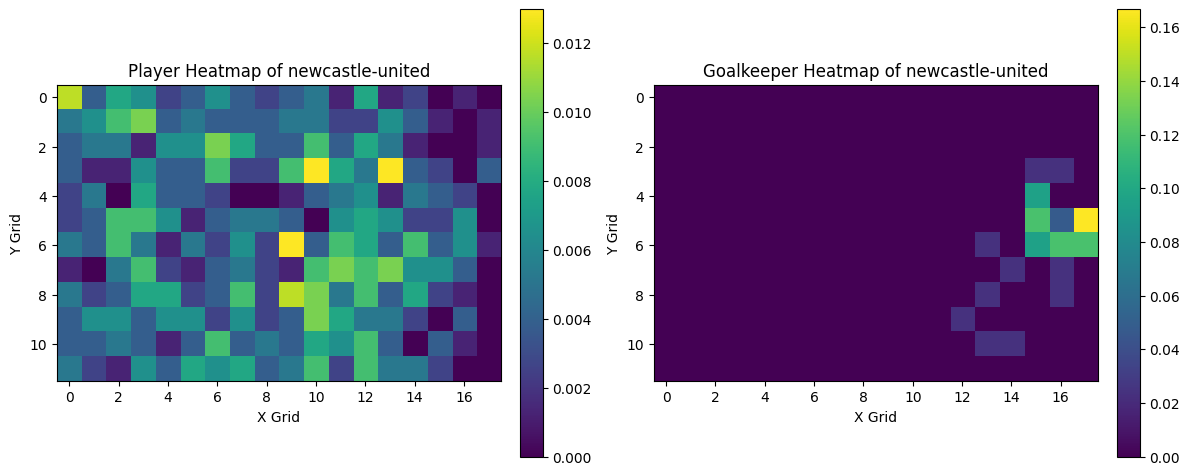

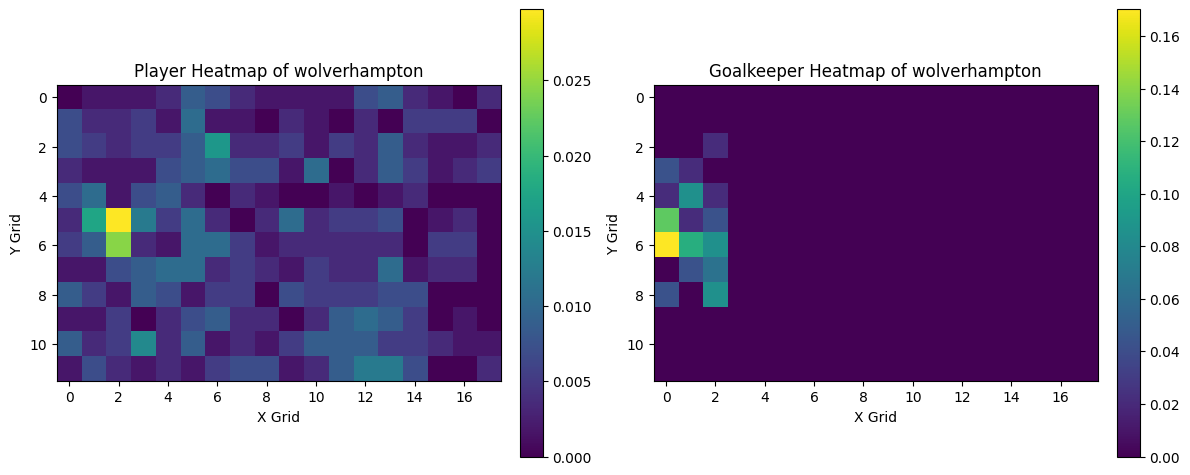

In [136]:
# Process the example heatmap into a 10x8 grid (for instance) with x-axis reversal turned off.
ene_equis = 18
ene_ye = 12
heatmap_index = -9
match_index = 115
team_name = test_dataset[match_index]['home_data']['team_names'][heatmap_index]
team_player_tensor = test_dataset[match_index]['home_data']['team_player_heatmap_sequence'][heatmap_index]
team_goalkeeper_tensor = test_dataset[match_index]['home_data']['team_goalkeeper_heatmap_sequence'][heatmap_index]

enemy_name = test_dataset[match_index]['home_data']['enemy_names'][heatmap_index]
enemy_player_tensor = test_dataset[match_index]['home_data']['enemy_player_heatmap_sequence'][heatmap_index]
enemy_goalkeeper_tensor = test_dataset[match_index]['home_data']['enemy_goalkeeper_heatmap_sequence'][heatmap_index]

print(test_dataset[match_index]['home_data']['team_names'][heatmap_index],
    test_dataset[match_index]['home_data']['team_scores'][heatmap_index],
    test_dataset[match_index]['home_data']['is_home_sequence'][heatmap_index],
    test_dataset[match_index]['home_data']['enemy_names'][heatmap_index],
    test_dataset[match_index]['home_data']['enemy_scores'][heatmap_index],
    test_dataset[match_index]['home_data']['enemy_is_home_sequence'][heatmap_index])
#print("Player Heatmap Tensor (flattened):")
#print(player_tensor)

#print("\nGoalkeeper Heatmap Tensor (flattened):")
#print(goalkeeper_tensor)
my_map = create_single_color_colormap('blue', lightness_increase=0.1, lightness_decrease=0.2)
# Plot both heatmaps side-by-side
plot_team_heatmaps(team_player_tensor, team_goalkeeper_tensor, n_x=ene_equis, n_y=ene_ye,
                    player_title=f"Player Heatmap of {team_name}", goalkeeper_title=f"Goalkeeper Heatmap of {team_name}", cmap='viridis')
plot_team_heatmaps(enemy_player_tensor, enemy_goalkeeper_tensor, n_x=ene_equis, n_y=ene_ye,
                    player_title=f"Player Heatmap of {enemy_name}", goalkeeper_title=f"Goalkeeper Heatmap of {enemy_name}", cmap='viridis')

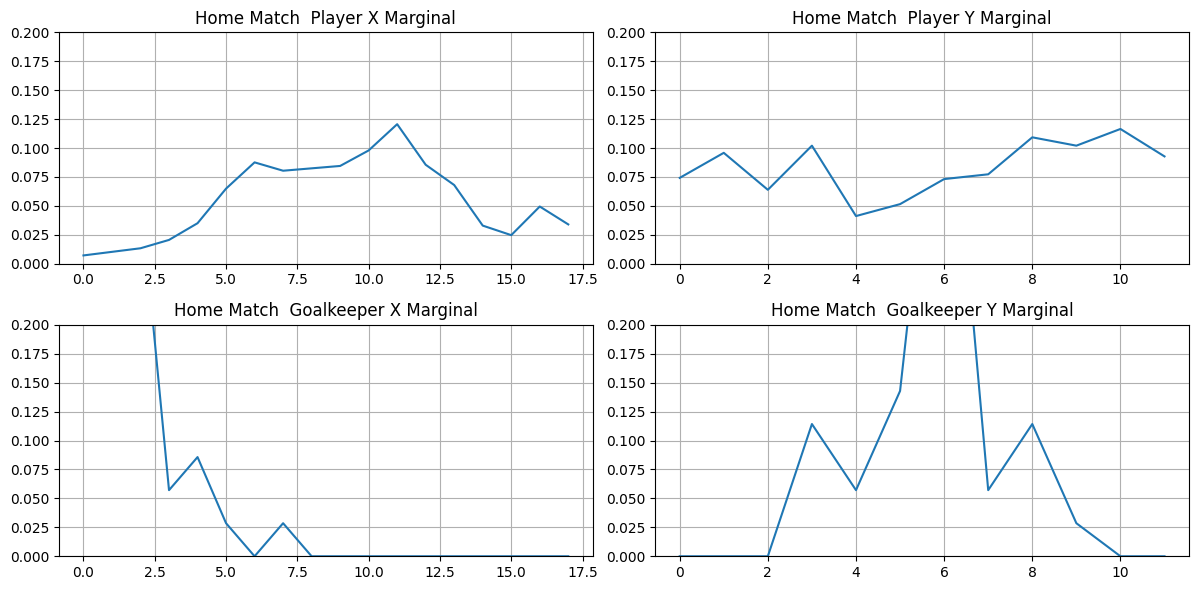

In [132]:
plot_heatmap_marginals(team_player_tensor, team_goalkeeper_tensor, title_prefix="Home Match ")

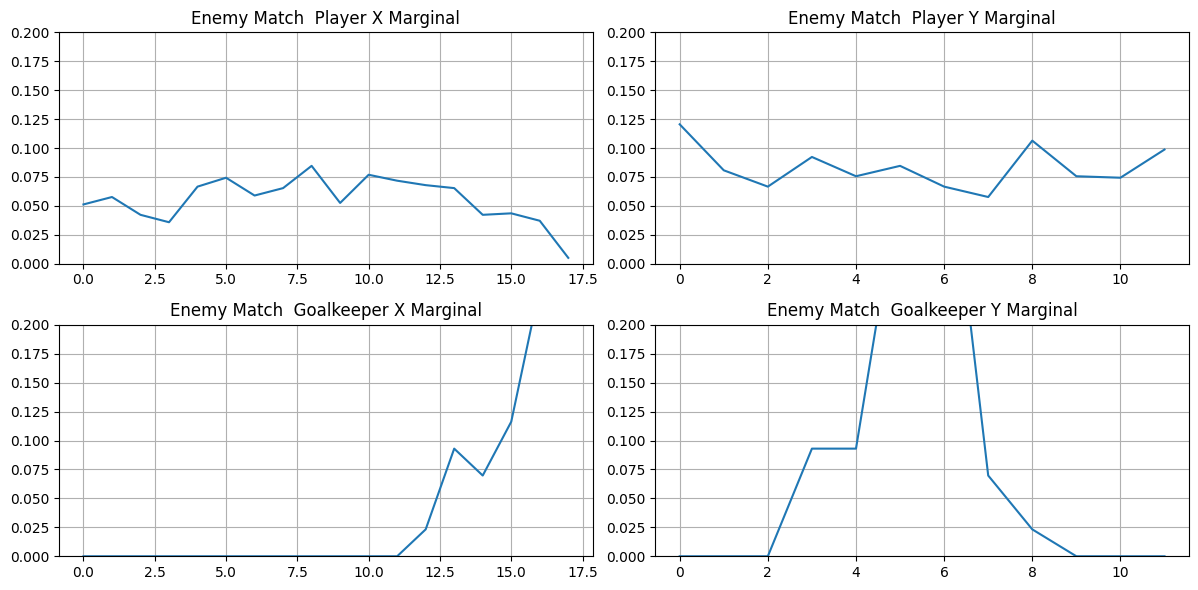

In [135]:
plot_heatmap_marginals(team_player_tensor, team_goalkeeper_tensor, title_prefix="Enemy Match ")

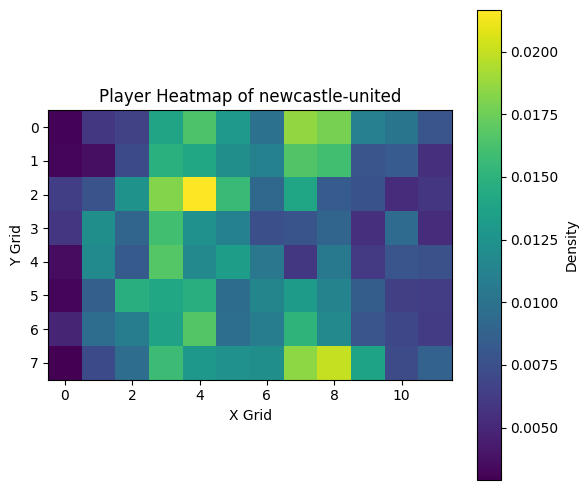

In [237]:
# Process the example heatmap into a 10x8 grid (for instance) with x-axis reversal turned off.
heatmap_index = -1
match_index = 115

stacked_player_tensor = torch.stack(test_dataset[match_index]['home_data']['team_player_heatmap_sequence'])
average_player_tensor = torch.mean(stacked_player_tensor, dim=0)
team_name = test_dataset[match_index]['home_data']['team_names'][heatmap_index]
#print("Player Heatmap Tensor (flattened):")
#print(player_tensor)

#print("\nGoalkeeper Heatmap Tensor (flattened):")
#print(goalkeeper_tensor)
my_map = create_single_color_colormap('blue', lightness_increase=0.1, lightness_decrease=0.2)
# Plot both heatmaps side-by-side
plot_heatmap(average_player_tensor, n_x=12, n_y=8,
                    title=f"Player Heatmap of {team_name}",  cmap='viridis')

In [16]:
lineups_df.apply(lambda row: row['home']['formation'], axis=1)

0      (5, 4, 1, 0)
1      (4, 3, 3, 0)
2      (4, 2, 3, 1)
3      (4, 2, 3, 1)
4      (4, 4, 1, 1)
           ...     
375    (3, 4, 2, 1)
376    (4, 3, 3, 0)
377    (3, 4, 3, 0)
378    (4, 1, 4, 1)
379    (5, 3, 2, 0)
Length: 380, dtype: object

In [5]:
period_test=['total','45_min','90_min']
team_atk_test=['accuratecross_all','accuratecross_value','accuratelongballs_all','accuratelongballs_value',
            'accuratepasses','accuratethroughball','bigchancecreated','bigchancescored','cornerkicks',
            'dribblespercentage_all','dribblespercentage_value','duelwonpercent','finalthirdentries',
            'fouledfinalthird','freekicks','passes','shotsongoal','totalshotsinsidebox','totalshotsongoal',
            'totalshotsoutsidebox']
team_def_test=['aerialduelspercentage_all','aerialduelspercentage_value','ballpossession','ballrecovery',
            'goalkeepersaves','groundduelspercentage_all','groundduelspercentage_value','interceptionwon',
            'throwins','totalclearance','wontacklepercent_all','wontacklepercent_value']
enemy_def_test=['bigchancemissed','blockedscoringattempt','dispossessed','hitwoodwork','offsides',
            'redcards','shotsoffgoal','yellowcards']
extra_test=['total_goalsprevented']

In [144]:
def pad_feature_to_batch_max(batch, feature_key, nested_key):
    """
    Pads a feature across the entire batch so that all matches for a feature have the same length,
    determined by the maximum length across all samples in the batch.

    Args:
        batch (list): A batch of samples, where each sample is a dictionary.
        feature_key (str): The main key in the dictionary (e.g., 'home_data' or 'away_data').
        nested_key (str): The specific feature to pad (e.g., 'team_shots', 'enemy_shots').

    Returns:
        None: Modifies the batch in place by padding the specified feature.
    """
    num_matches = len(batch[0][feature_key][nested_key])
    # Determine the maximum length for the feature across the batch
    max_length = max(len(sample[feature_key][nested_key][0]) for sample in batch)

    # Pad the feature in all matches for all samples
    for sample in batch:
        for match_idx in range(num_matches):
            current_length = len(sample[feature_key][nested_key][match_idx])
            pad_length = max_length - current_length

            if pad_length > 0:
                # Create padding for the match
                padding = [[0,0,0] for _ in range(pad_length)]
                sample[feature_key][nested_key][match_idx] = sample[feature_key][nested_key][match_idx] + padding
                #print(len(sample[feature_key][nested_key][match_idx]))
                
def create_valid_mask(scores_lengths, max_seq_length):
    """
    Create a binary mask for padded timesteps.
    
    Args:
        scores_lengths (Tensor): shape (batch_size,), each value is n (the number of historical matches).
        max_seq_length (int):   total sequence length (padded) in each sample.
    
    Returns:
        mask (Tensor): shape (batch_size, max_seq_length), 
                    with 1 for valid timesteps, 0 for padded timesteps.
    """
    batch_size = scores_lengths.size(0)
    mask = torch.zeros(batch_size, max_seq_length, dtype=torch.float)

    for i in range(batch_size):
        n = scores_lengths[i].item()  # number of historical matches
        # We also include the current match, so valid region is the last (n+1) timesteps
        start_index = max_seq_length - (n + 1)

        # Clamp just in case n+1 exceeds max_seq_length
        if start_index < 0:
            start_index = 0

        mask[i, start_index:] = 1.0

    return mask.unsqueeze(-1).float()


In [145]:
# Collate function
def collate_fn(batch):
    # Initialize lists to collect batched data
    batch_size = len(batch)

    # Pad features for home_data and away_data (as before)
    features_to_pad = ['team_shots', 'enemy_shots', 'team_penalties', 'enemy_penalties', 'team_owngoals', 'enemy_owngoals']
    for feature in features_to_pad:
        pad_feature_to_batch_max(batch, feature_key='home_data', nested_key=feature)
    for feature in features_to_pad:
        pad_feature_to_batch_max(batch, feature_key='away_data', nested_key=feature)
    
    # Process home_data features
    home_team_names_list = [sample['home_data']['team_names'] for sample in batch]
    home_enemy_names_list = [sample['home_data']['enemy_names'] for sample in batch]
    home_team_index_tensor = torch.tensor([sample['home_data']['team_index'] for sample in batch], dtype=torch.long)
    home_enemy_index_tensor = torch.tensor([sample['home_data']['enemy_index'] for sample in batch], dtype=torch.long)
    home_team_scores_tensor = torch.tensor([sample['home_data']['team_scores'] for sample in batch])
    home_enemy_scores_tensor = torch.tensor([sample['home_data']['enemy_scores'] for sample in batch])
    home_team_scores_lengths_tensor = torch.tensor([sample['home_data']['team_scores_length'] for sample in batch])
    home_team_formations_tensor = torch.tensor([sample['home_data']['team_formations'] for sample in batch]).unsqueeze(-1).float()
    home_enemy_formations_tensor = torch.tensor([sample['home_data']['enemy_formations'] for sample in batch]).unsqueeze(-1).float()
    home_team_standings_sequence_tensor = torch.tensor([sample['home_data']['team_standings'] for sample in batch]).unsqueeze(-1).float()
    home_enemy_standings_sequence_tensor = torch.tensor([sample['home_data']['enemy_standings'] for sample in batch]).unsqueeze(-1).float()
    home_is_home_sequence_tensor = torch.tensor([sample['home_data']['is_home_sequence'] for sample in batch]).unsqueeze(-1).float()
    home_enemy_is_home_tensor = torch.tensor([sample['home_data']['enemy_is_home_sequence'] for sample in batch]).unsqueeze(-1).float()
    home_team_atk_sequence_np = np.array([sample['home_data']['team_atk'] for sample in batch])
    home_team_atk_sequence_tensor = torch.tensor(home_team_atk_sequence_np, dtype=torch.float)
    home_enemy_atk_sequence_np = np.array([sample['home_data']['enemy_atk'] for sample in batch])
    home_enemy_atk_sequence_tensor = torch.tensor(home_enemy_atk_sequence_np, dtype=torch.float)
    home_team_def_sequence_np = np.array([sample['home_data']['team_def'] for sample in batch])
    home_team_def_sequence_tensor = torch.tensor(home_team_def_sequence_np, dtype=torch.float)
    home_enemy_def_sequence_np = np.array([sample['home_data']['enemy_def'] for sample in batch])
    home_enemy_def_sequence_tensor = torch.tensor(home_enemy_def_sequence_np, dtype=torch.float)
    home_team_shots_sequence_tensor = torch.tensor([sample['home_data']['team_shots'] for sample in batch])
    home_enemy_shots_sequence_tensor = torch.tensor([sample['home_data']['enemy_shots'] for sample in batch])
    home_team_penalties_sequence_tensor = torch.tensor([sample['home_data']['team_penalties'] for sample in batch])
    home_enemy_penalties_sequence_tensor = torch.tensor([sample['home_data']['enemy_penalties'] for sample in batch])
    home_team_owngoals_sequence_tensor = torch.tensor([sample['home_data']['team_owngoals'] for sample in batch])
    home_enemy_owngoals_sequence_tensor = torch.tensor([sample['home_data']['enemy_owngoals'] for sample in batch])
    home_team_shots_lengths_tensor = torch.tensor([sample['home_data']['team_shots_length'] for sample in batch])
    home_enemy_shots_lengths_tensor = torch.tensor([sample['home_data']['enemy_shots_length'] for sample in batch])
    
    # Process heatmap sequences for home_data using torch.stack
    home_player_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['home_data']['team_player_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    home_goalkeeper_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['home_data']['team_goalkeeper_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    home_enemy_player_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['home_data']['enemy_player_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    home_enemy_goalkeeper_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['home_data']['enemy_goalkeeper_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    
    max_seq_length = home_team_atk_sequence_tensor.shape[1]
    home_team_valid_mask = create_valid_mask(home_team_scores_lengths_tensor, max_seq_length)
    
    # Process away_data features (similar to home_data)
    away_team_names_list = [sample['away_data']['team_names'] for sample in batch]
    away_enemy_names_list = [sample['away_data']['enemy_names'] for sample in batch]
    away_team_index_tensor = torch.tensor([sample['away_data']['team_index'] for sample in batch], dtype=torch.long)
    away_enemy_index_tensor = torch.tensor([sample['away_data']['enemy_index'] for sample in batch], dtype=torch.long)
    away_team_scores_tensor = torch.tensor([sample['away_data']['team_scores'] for sample in batch])
    away_enemy_scores_tensor = torch.tensor([sample['away_data']['enemy_scores'] for sample in batch])
    away_team_scores_lengths_tensor = torch.tensor([sample['away_data']['team_scores_length'] for sample in batch])
    away_team_formations_tensor = torch.tensor([sample['away_data']['team_formations'] for sample in batch]).unsqueeze(-1).float()
    away_enemy_formations_tensor = torch.tensor([sample['away_data']['enemy_formations'] for sample in batch]).unsqueeze(-1).float()
    away_team_standings_sequence_tensor = torch.tensor([sample['away_data']['team_standings'] for sample in batch]).unsqueeze(-1).float()
    away_enemy_standings_sequence_tensor = torch.tensor([sample['away_data']['enemy_standings'] for sample in batch]).unsqueeze(-1).float()
    away_is_home_sequence_tensor = torch.tensor([sample['away_data']['is_home_sequence'] for sample in batch]).unsqueeze(-1).float()
    away_enemy_is_home_tensor = torch.tensor([sample['away_data']['enemy_is_home_sequence'] for sample in batch]).unsqueeze(-1).float()
    away_team_atk_sequence_np = np.array([sample['away_data']['team_atk'] for sample in batch])
    away_team_atk_sequence_tensor = torch.tensor(away_team_atk_sequence_np, dtype=torch.float)
    away_enemy_atk_sequence_np = np.array([sample['away_data']['enemy_atk'] for sample in batch])
    away_enemy_atk_sequence_tensor = torch.tensor(away_enemy_atk_sequence_np, dtype=torch.float)
    away_team_def_sequence_np = np.array([sample['away_data']['team_def'] for sample in batch])
    away_team_def_sequence_tensor = torch.tensor(away_team_def_sequence_np, dtype=torch.float)
    away_enemy_def_sequence_np = np.array([sample['away_data']['enemy_def'] for sample in batch])
    away_enemy_def_sequence_tensor = torch.tensor(away_enemy_def_sequence_np, dtype=torch.float)
    away_team_shots_sequence_tensor = torch.tensor([sample['away_data']['team_shots'] for sample in batch])
    away_enemy_shots_sequence_tensor = torch.tensor([sample['away_data']['enemy_shots'] for sample in batch])
    away_team_penalties_sequence_tensor = torch.tensor([sample['away_data']['team_penalties'] for sample in batch])
    away_enemy_penalties_sequence_tensor = torch.tensor([sample['away_data']['enemy_penalties'] for sample in batch])
    away_team_owngoals_sequence_tensor = torch.tensor([sample['away_data']['team_owngoals'] for sample in batch])
    away_enemy_owngoals_sequence_tensor = torch.tensor([sample['away_data']['enemy_owngoals'] for sample in batch])
    away_team_shots_lengths_tensor = torch.tensor([sample['away_data']['team_shots_length'] for sample in batch])
    away_enemy_shots_lengths_tensor = torch.tensor([sample['away_data']['enemy_shots_length'] for sample in batch])
    
    # Process heatmap sequences for away_data using torch.stack
    away_player_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['away_data']['team_player_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    away_goalkeeper_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['away_data']['team_goalkeeper_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    away_enemy_player_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['away_data']['enemy_player_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    away_enemy_goalkeeper_heatmap_seq_tensor = torch.stack([
    torch.stack([torch.as_tensor(h, dtype=torch.float32) for h in sample['away_data']['enemy_goalkeeper_heatmap_sequence']])
    for sample in batch
    ], dim=0)
    
    away_team_valid_mask = create_valid_mask(away_team_scores_lengths_tensor, max_seq_length)
    
    outcomes_tensor = torch.tensor([sample['outcome'] for sample in batch])
    league_index_tensor = torch.tensor([sample['league_index'] for sample in batch])
    
    # Create batch_data dictionary
    batch_data = {
        # Home team data
        'home_team_names': home_team_names_list,
        'home_enemy_names': home_enemy_names_list,
        'home_team_index': home_team_index_tensor,
        'home_enemy_index': home_enemy_index_tensor,
        'home_team_scores': home_team_scores_tensor,
        'home_enemy_scores': home_enemy_scores_tensor,
        'home_team_scores_lengths': home_team_scores_lengths_tensor,
        'home_team_formations': home_team_formations_tensor,
        'home_enemy_formations': home_enemy_formations_tensor,
        'home_team_standings': home_team_standings_sequence_tensor,
        'home_enemy_standings': home_enemy_standings_sequence_tensor,
        'home_team_is_home': home_is_home_sequence_tensor,
        'home_enemy_is_home': home_enemy_is_home_tensor,
        'home_team_atk': home_team_atk_sequence_tensor,
        'home_enemy_atk': home_enemy_atk_sequence_tensor,
        'home_team_def': home_team_def_sequence_tensor,
        'home_enemy_def': home_enemy_def_sequence_tensor,
        'home_team_shots': home_team_shots_sequence_tensor,
        'home_enemy_shots': home_enemy_shots_sequence_tensor,
        'home_team_penalties': home_team_penalties_sequence_tensor,
        'home_enemy_penalties': home_enemy_penalties_sequence_tensor,
        'home_team_owngoals': home_team_owngoals_sequence_tensor,
        'home_enemy_owngoals': home_enemy_owngoals_sequence_tensor,
        'home_team_shots_lengths': home_team_shots_lengths_tensor,
        'home_enemy_shots_lengths': home_enemy_shots_lengths_tensor,
        'home_team_valid_mask': home_team_valid_mask,
        # New heatmap sequences for home team
        'home_team_player_heatmap_sequence': home_player_heatmap_seq_tensor,
        'home_team_goalkeeper_heatmap_sequence': home_goalkeeper_heatmap_seq_tensor,
        'home_enemy_player_heatmap_sequence': home_enemy_player_heatmap_seq_tensor,
        'home_enemy_goalkeeper_heatmap_sequence': home_enemy_goalkeeper_heatmap_seq_tensor,
        
        # Outcome and league data
        'outcomes': outcomes_tensor,
        'leagues': league_index_tensor,
    
        # Away team data
        'away_team_names': away_team_names_list,
        'away_enemy_names': away_enemy_names_list,
        'away_team_index': away_team_index_tensor,
        'away_enemy_index': away_enemy_index_tensor,
        'away_team_scores': away_team_scores_tensor,
        'away_enemy_scores': away_enemy_scores_tensor,
        'away_team_scores_lengths': away_team_scores_lengths_tensor,
        'away_team_formations': away_team_formations_tensor,
        'away_enemy_formations': away_enemy_formations_tensor,
        'away_team_standings': away_team_standings_sequence_tensor,
        'away_enemy_standings': away_enemy_standings_sequence_tensor,
        'away_team_is_home': away_is_home_sequence_tensor,
        'away_enemy_is_home': away_enemy_is_home_tensor,
        'away_team_atk': away_team_atk_sequence_tensor,
        'away_enemy_atk': away_enemy_atk_sequence_tensor,
        'away_team_def': away_team_def_sequence_tensor,
        'away_enemy_def': away_enemy_def_sequence_tensor,
        'away_team_shots': away_team_shots_sequence_tensor,
        'away_enemy_shots': away_enemy_shots_sequence_tensor,
        'away_team_penalties': away_team_penalties_sequence_tensor,
        'away_enemy_penalties': away_enemy_penalties_sequence_tensor,
        'away_team_owngoals': away_team_owngoals_sequence_tensor,
        'away_enemy_owngoals': away_enemy_owngoals_sequence_tensor,
        'away_team_shots_lengths': away_team_shots_lengths_tensor,
        'away_enemy_shots_lengths': away_enemy_shots_lengths_tensor,
        'away_team_valid_mask': away_team_valid_mask,
        # New heatmap sequences for away team
        'away_team_player_heatmap_sequence': away_player_heatmap_seq_tensor,
        'away_team_goalkeeper_heatmap_sequence': away_goalkeeper_heatmap_seq_tensor,
        'away_enemy_player_heatmap_sequence': away_enemy_player_heatmap_seq_tensor,
        'away_enemy_goalkeeper_heatmap_sequence': away_enemy_goalkeeper_heatmap_seq_tensor
    }
    return batch_data


In [182]:
# Get a batch of data
batch = [test_dataset[i+500] for i in range(32)]
batch_data = collate_fn(batch)
#features_to_pad = ['team_shots', 'enemy_shots','team_penalties','enemy_penalties','team_owngoals','enemy_owngoals']
#for feature in features_to_pad:
#    pad_feature_to_batch_max(batch, feature_key='home_data', nested_key=feature)

In [147]:
batch_data['home_team_player_heatmap_sequence'].shape

torch.Size([32, 31, 12, 18])

In [ ]:
def build_datasets(league_df, lineups_df,train_p,val_p,history_length=8):
    assert train_p + val_p<= 1, "Train, validation, and test proportions must not exceed 1."
    #player_stats = get_player_stats(lineups_df)
    
    dataset = FootballDataset(league_df, lineups_df, history_length)
    #Slices for the dataset
    train_size = int(train_p * len(dataset))
    train_indices = list(range(train_size))
    val_size = int(val_p * len(dataset))
    val_indices = list(range(train_size,train_size+val_size))
    test_indices = list(range(train_size+val_size,len(dataset)))
    
    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)
    test_dataset = Subset(dataset, test_indices)
    
    return train_dataset, val_dataset, test_dataset
# Build loaders
def build_train_loader(train_dataset, batch_size=32):
    return DataLoader(train_dataset, batch_size=batch_size,
                    shuffle=True, collate_fn=collate_fn, num_workers=8, pin_memory=True)

def build_val_loader(val_dataset, batch_size=32):
    return DataLoader(val_dataset, batch_size=batch_size,
                    shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)

def build_test_loader(test_dataset, batch_size=32):
    return DataLoader(test_dataset, batch_size=batch_size,
                    shuffle=False, collate_fn=collate_fn, num_workers=8, pin_memory=True)
    
    
#Construct a pre-computed dataset
def precompute_data(dataset, output_dir, start_idx=0):
    """
    Precompute dataset and save preprocessed samples to disk.
    
    Args:
        dataset (torch.utils.data.Dataset): The dataset to preprocess.
        output_dir (str): Directory to save preprocessed data.
        start_idx (int): Index to start precomputing from (useful for resuming).

    Returns:
        None
    """
    os.makedirs(output_dir, exist_ok=True)
    
    for idx in range(start_idx, len(dataset)):
        try:
            # Fetch raw sample from dataset
            sample = dataset[idx]
            
            # Perform preprocessing (if required in dataset)
            preprocessed_sample = {
                'home_data': sample['home_data'],  # Already preprocessed if from Dataset class
                'away_data': sample['away_data'],
                'outcome': sample['outcome']
            }
            
            # Save preprocessed sample
            file_path = os.path.join(output_dir, f"sample_{idx}.pt")
            torch.save(preprocessed_sample, file_path)
            
            print(f"Preprocessed and saved sample {idx + 1}/{len(dataset)}")
        except Exception as e:
            print(f"Error processing sample {idx}: {e}")
            continue

    print("Preprocessing complete!")
    
#Create a class to load pre-processed samples
class PrecomputedFootballDataset(Dataset):
    """
    Dataset class to load precomputed samples.
    """
    def __init__(self, precomputed_dir):
        """
        Args:
            precomputed_dir (str): Path to directory containing precomputed .pt files.
        """
        self.file_paths = sorted([os.path.join(precomputed_dir, f) 
                                for f in os.listdir(precomputed_dir) if f.endswith('.pt')])

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])
    
#Build precomputed datasets
def build_datasets_from_files(precomputed_dir, train_p, val_p):
    """
    Build datasets from precomputed files.

    Args:
        precomputed_dir (str): Base directory containing precomputed data.
        train_p (float): Proportion of data for training.
        val_p (float): Proportion of data for validation.

    Returns:
        train_dataset, val_dataset, test_dataset
    """
    assert train_p + val_p <= 1, "Train, validation, and test proportions must not exceed 1."

    # Load all precomputed files
    dataset = PrecomputedFootballDataset(precomputed_dir)

    # Calculate dataset splits
    train_size = int(train_p * len(dataset))
    val_size = int(val_p * len(dataset))
    test_size = len(dataset) - train_size - val_size

    # Split indices
    train_indices = list(range(train_size))
    val_indices = list(range(train_size, train_size + val_size))
    test_indices = list(range(train_size + val_size, len(dataset)))

    # Create subsets
    train_dataset = Subset(dataset, train_indices)
    val_dataset = Subset(dataset, val_indices)
    test_dataset = Subset(dataset, test_indices)

    return train_dataset, val_dataset, test_dataset


In [10]:
def prep_histogram(sample):
    num_matches = sample['home_data']['team_scores_length']+1
    num_shots = [item[0] for item in sample['home_data']['team_shots_length'][-num_matches:]]
    shots = sample['home_data']['team_shots'][-num_matches:]
    shots_list = []
    for i in range(num_matches):
        match_shots = [shots[i][j][0] for j in range(num_shots[i])]
        shots_list += match_shots
    return shots_list

In [11]:
hist_data = prep_histogram(batch[20])
hist_name = batch[20]['home_data']['team_names'][-1]

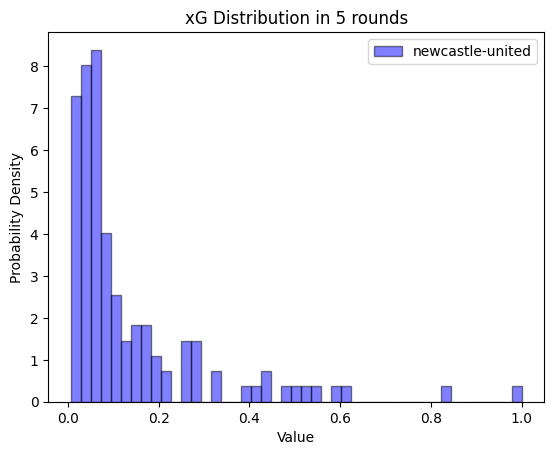

In [12]:
num_bins = 45
plt.hist(hist_data, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name)


plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('xG Distribution in 5 rounds')
plt.legend()

# Show plot
plt.show()

In [19]:
hist_data1 = prep_histogram(batch[20])
hist_name1 = batch[20]['home_data']['team_names'][-1]
hist_data2 = prep_histogram(batch[21])
hist_name2 = batch[21]['home_data']['team_names'][-1]
hist_data3 = prep_histogram(batch[22])
hist_name3 = batch[22]['home_data']['team_names'][-1]
hist_data4 = prep_histogram(batch[23])
hist_name4 = batch[23]['home_data']['team_names'][-1]
hist_data5 = prep_histogram(batch[24])
hist_name5 = batch[24]['home_data']['team_names'][-1]
hist_data6 = prep_histogram(batch[19])
hist_name6 = batch[19]['home_data']['team_names'][-1]
alldata=hist_data1+hist_data2+hist_data3+hist_data4+hist_data5+hist_data6

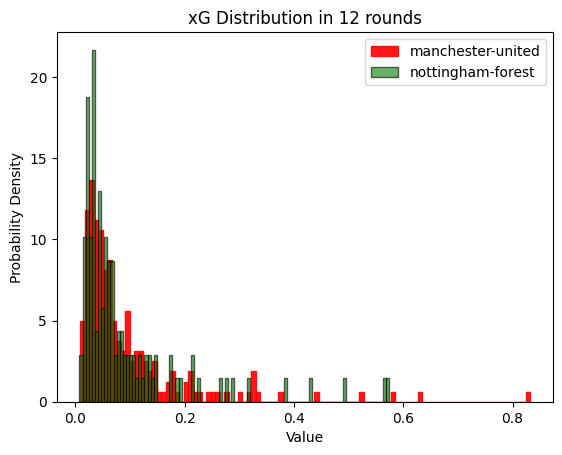

In [65]:
num_bins = 100
#plt.hist(hist_data1, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name1)
#plt.hist(hist_data2, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name2)
#plt.hist(hist_data3, bins=num_bins, density=True, alpha=0.5, color='green', edgecolor='black', label=hist_name3)
#plt.hist(hist_data4, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name4)
plt.hist(hist_data6, bins=num_bins, density=True, alpha=0.9, color='red', edgecolor='red', label=hist_name6)
plt.hist(hist_data5, bins=num_bins, density=True, alpha=0.6, color='green', edgecolor='black', label=hist_name5)
#plt.hist(hist_data6, bins=num_bins, density=True, alpha=1.0, color='red', edgecolor='black', label=hist_name6)
#plt.hist(alldata, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label='Premier League')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('xG Distribution in 12 rounds')
plt.legend()

# Show plot
plt.show()

In [193]:
batch[19]['home_data']['team_names']

['manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united',
 'manchester-united']

In [74]:
def prep_histogram_corners(sample):
    num_matches = sample['home_data']['team_scores_length']+1
    corners = [sample['home_data']['team_atk'][-i][17] for i in range(1,num_matches+1)]

    return corners

In [10]:
test_dataset.atk_headers[8]

'total_cornerkicks'

In [7]:
test_dataset[50]['home_data']['team_atk'][-8:]

NameError: name 'test_dataset' is not defined

In [31]:
[test_dataset[50]['home_data']['team_atk'][-i][8] for i in range(1,len(test_dataset[50]['home_data']['team_atk'])+1)]

[3.0, 2.0, 4.0, 6.0, 1.0, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [75]:
hist_data1 = prep_histogram_corners(batch[20])
hist_name1 = batch[20]['home_data']['team_names'][-1]
hist_data2 = prep_histogram_corners(batch[21])
hist_name2 = batch[21]['home_data']['team_names'][-1]
hist_data3 = prep_histogram_corners(batch[22])
hist_name3 = batch[22]['home_data']['team_names'][-1]
hist_data4 = prep_histogram_corners(batch[23])
hist_name4 = batch[23]['home_data']['team_names'][-1]
hist_data5 = prep_histogram_corners(batch[24])
hist_name5 = batch[24]['home_data']['team_names'][-1]
hist_data6 = prep_histogram_corners(batch[25])
hist_name6 = batch[25]['home_data']['team_names'][-1]
hist_data7 = prep_histogram_corners(batch[19])
hist_name7 = batch[19]['home_data']['team_names'][-1]
hist_data8 = prep_histogram_corners(batch[18])
hist_name8 = batch[18]['home_data']['team_names'][-1]
hist_data9 = prep_histogram_corners(batch[17])
hist_name9 = batch[17]['home_data']['team_names'][-1]
alldata=hist_data1+hist_data2+hist_data3+hist_data4+hist_data5+hist_data6+hist_data7+hist_data8+hist_data9

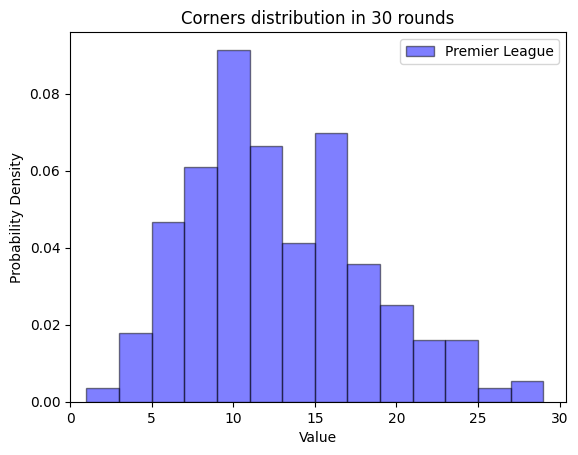

In [137]:
num_bins = 14
#plt.hist(hist_data1, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name1)
#plt.hist(hist_data2, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name2)
#plt.hist(hist_data3, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name3)
#plt.hist(hist_data4, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name4)
#plt.hist(hist_data5, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name5)
#plt.hist(hist_data6, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name6)
#plt.hist(hist_data7, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name7)
#plt.hist(hist_data8, bins=num_bins, density=True, alpha=0.5, color='red', edgecolor='black', label=hist_name8)
#plt.hist(hist_data9, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label=hist_name9)
plt.hist(alldata, bins=num_bins, density=True, alpha=0.5, color='blue', edgecolor='black', label='Premier League')

plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Corners distribution in 30 rounds')
plt.legend()
plt.xlim(left=0)

# Show plot
plt.show()

In [175]:
np.mean(hist_data5)

5.387097

In [176]:
np.var(hist_data5)

7.140479

In [32]:
test_dataset[100]['home_data']['team_standings']

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 10.0,
 6.0,
 14.0,
 12.0,
 13.0,
 10.0,
 12.0,
 13.0,
 13.0,
 14.0,
 14.0]

In [31]:
test_dataset.mis_headers

['total_bigchancemissed',
 'total_blockedscoringattempt',
 'total_dispossessed',
 'total_hitwoodwork',
 'total_offsides',
 'total_redcards',
 'total_shotsoffgoal',
 'total_yellowcards',
 '45_min_bigchancemissed',
 '45_min_blockedscoringattempt',
 '45_min_dispossessed',
 '45_min_hitwoodwork',
 '45_min_offsides',
 '45_min_redcards',
 '45_min_shotsoffgoal',
 '45_min_yellowcards',
 '90_min_bigchancemissed',
 '90_min_blockedscoringattempt',
 '90_min_dispossessed',
 '90_min_hitwoodwork',
 '90_min_offsides',
 '90_min_redcards',
 '90_min_shotsoffgoal',
 '90_min_yellowcards']

In [2]:
50*2882.30+2816.75*40+10*2816.50

284950.0

In [3]:
290378-284950

5428

In [4]:
103897/284950

0.36461484470959815

In [5]:
5428*0.36461484470959815

1979.1293770836987

In [6]:
103897+1979.1293770836987

105876.1293770837